# 05 Univariate Analysis

## Objective

Objective:
Perform univariate analysis to understand the distribution,
patterns, and characteristics of individual features.

This step helps in:
- Understanding data distribution
- Identifying skewness and outliers
- Detecting imbalance in categorical features
- Preparing for feature engineering and modeling


## Imports


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

project_root = Path.cwd()
if not (project_root / "src").exists() and (project_root.parent / "src").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.config import CATEGORICAL_COLUMNS, NUMERICAL_COLUMNS, TARGET_COLUMN
from src.data.data_loader import load_cleaned_data

sns.set_theme(style="whitegrid")


## Load Data and Separate Column Types


In [2]:
df = load_cleaned_data()
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
target_column = TARGET_COLUMN
numerical_columns = [column for column in NUMERICAL_COLUMNS if column in df.columns]
categorical_columns = [column for column in CATEGORICAL_COLUMNS if column in df.columns]
binary_columns = [
    column
    for column in categorical_columns
    if df[column].dropna().nunique() == 2
]

column_groups = {
    "numerical_columns": numerical_columns,
    "categorical_columns": categorical_columns,
    "binary_columns": binary_columns,
    "target_column": target_column,
}

column_groups


{'numerical_columns': ['tenure', 'MonthlyCharges', 'TotalCharges'],
 'categorical_columns': ['gender',
  'SeniorCitizen',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod'],
 'binary_columns': ['gender',
  'SeniorCitizen',
  'Partner',
  'Dependents',
  'PhoneService',
  'PaperlessBilling'],
 'target_column': 'Churn'}

## Target Column Analysis

Analyze the target column on its own to understand class counts, class percentages, and the degree of class imbalance before moving to feature-level analysis.


In [5]:
target_counts = df[target_column].value_counts().sort_index()
target_percentages = df[target_column].value_counts(normalize=True).sort_index().mul(100).round(2)

imbalance_ratio = round(target_counts.max() / target_counts.min(), 2)

if imbalance_ratio < 1.5:
    imbalance_level = "Low imbalance"
elif imbalance_ratio < 3:
    imbalance_level = "Moderate imbalance"
else:
    imbalance_level = "High imbalance"

target_summary = pd.DataFrame({
    "class_count": target_counts,
    "class_percentage": target_percentages,
})

display(target_summary)
print(f"Imbalance ratio (majority/minority): {imbalance_ratio}:1")
print(f"Imbalance level: {imbalance_level}")


,class_count,class_percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


Imbalance ratio (majority/minority): 2.77:1
Imbalance level: Moderate imbalance


/var/folders/1l/ddpthpdj6j75gsq02qk0x0kc0000gn/T/ipykernel_39113/933255990.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=target_column, order=target_counts.index, palette="Set2")


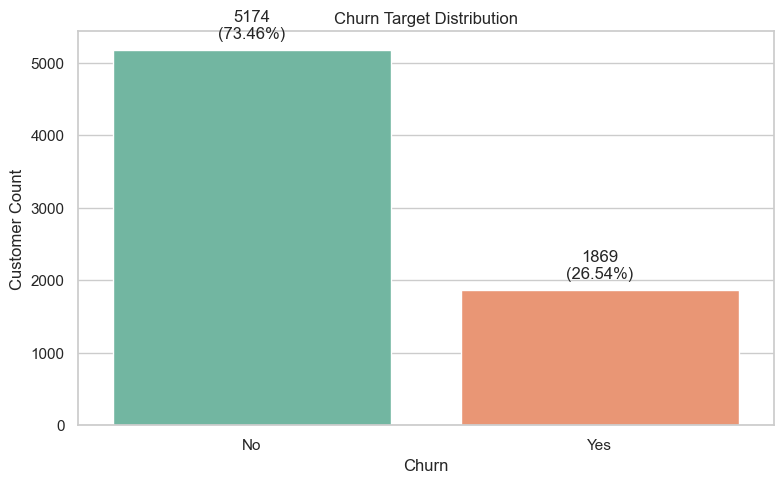

In [6]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x=target_column, order=target_counts.index, palette="Set2")

for patch, label in zip(ax.patches, target_counts.index):
    count = int(target_counts[label])
    percentage = target_percentages[label]
    ax.annotate(
        f"{count}\n({percentage}%)",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 6),
        textcoords="offset points",
    )

ax.set_title("Churn Target Distribution")
ax.set_xlabel(target_column)
ax.set_ylabel("Customer Count")
plt.tight_layout()
plt.show()


The target classes are moderately imbalanced. In this dataset, `No` is the majority class and `Yes` is the minority class, so downstream evaluation should rely on metrics beyond plain accuracy.
